## 1. Carga y Exploración de Datos

Dataset cargado exitosamente. Primeras 5 filas:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-

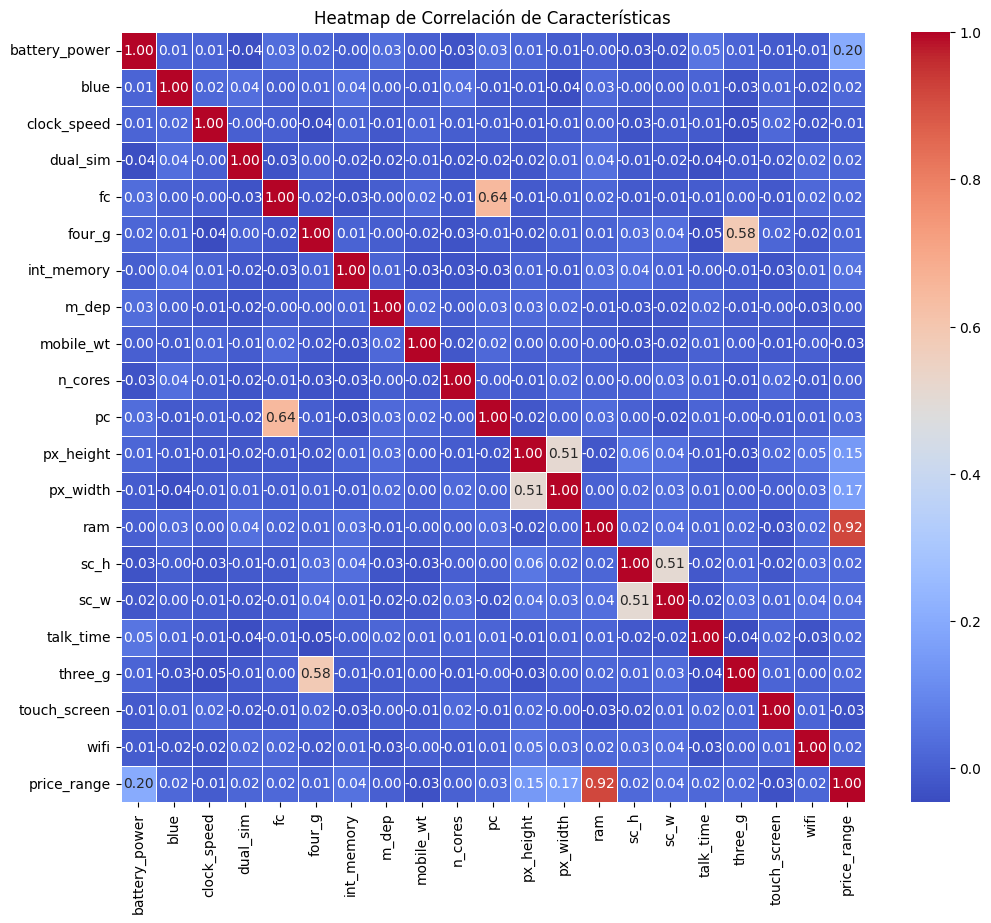

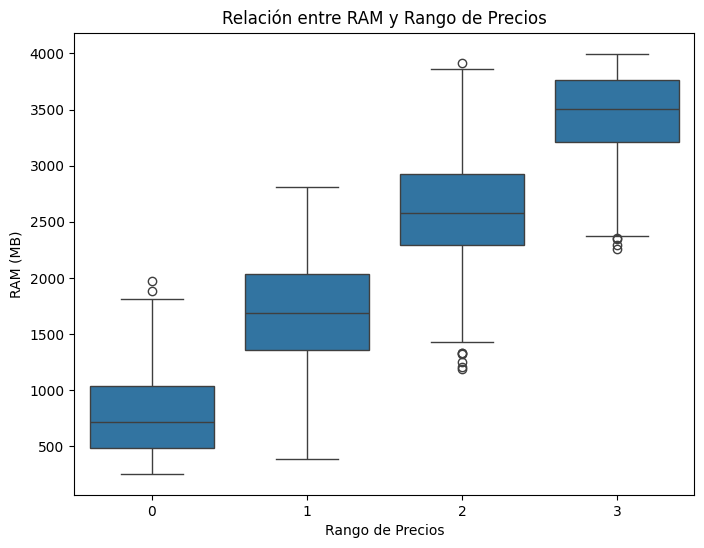

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import random

# URL del dataset 'Mobile Price Classification'
# La URL anterior (tofighi) ya no funciona. Se ha buscado una alternativa.
# La alternativa anterior (subashgandyer) tampoco funciona. Se ha encontrado otra.
# La alternativa anterior (mdabdullahadnan) tampoco funciona. Se ha encontrado otra.
# El usuario ha proporcionado un nuevo enlace de GitHub.
data_url = 'https://raw.githubusercontent.com/arpita-maji/Mobile-Price-Classification/master/mobile_price_range_data.csv'
df = pd.read_csv(data_url)

print("Dataset cargado exitosamente. Primeras 5 filas:")
# Muestra las primeras 5 filas del DataFrame
display(df.head())

print("\nInformación del DataFrame:")
df.info()

# Calcula la matriz de correlación
correlation_matrix = df.corr()

plt.figure(figsize=(12, 10))
# Genera un Heatmap de correlación para visualizar la relación entre las características
# y, específicamente, cómo influye la RAM en el precio.
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlación de Características')
plt.show()

# Visualización específica de la correlación entre 'ram' y 'price_range'
plt.figure(figsize=(8, 6))
sns.boxplot(x='price_range', y='ram', data=df)
plt.title('Relación entre RAM y Rango de Precios')
plt.xlabel('Rango de Precios')
plt.ylabel('RAM (MB)')
plt.show()

## 2. Preparación de Datos

In [ ]:
# Separar características (X) y la variable objetivo (y)
X = df.drop('price_range', axis=1)
y = df['price_range']

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
# random_state asegura la reproducibilidad de la división
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

# Escalado de características utilizando StandardScaler
# Inicializa el escalador
scaler = StandardScaler()

# Ajusta el escalador a los datos de entrenamiento y los transforma
X_train_scaled = scaler.fit_transform(X_train)
# Transforma los datos de prueba usando el mismo escalador (es crucial no reajustar)
X_test_scaled = scaler.transform(X_test)

print("Características escaladas exitosamente.")


Tamaño del conjunto de entrenamiento: 1600 muestras
Tamaño del conjunto de prueba: 400 muestras
Características escaladas exitosamente.


## 3. Funciones Explícitas del Algoritmo Genético

Aquí definimos las funciones clave que implementan la lógica del Algoritmo Genético paso a paso.

In [ ]:
# Rango para el hiperparámetro 'k' (n_neighbors)
# k debe ser un entero positivo y generalmente impar. Limitamos el rango para la búsqueda.
# El valor máximo se establece en 30 o la raíz cuadrada del número de muestras de entrenamiento, el que sea menor.
max_k = min(30, int(np.sqrt(X_train_scaled.shape[0])))
rango_k = range(1, max_k + 1, 2) # Solo números impares

def inicializar_poblacion(tam_poblacion, rango_k):
    """
    Inicializa una población de cromosomas aleatorios.
    Cada cromosoma es una lista con un solo gen: el valor de 'k' para KNN.
    """
    poblacion = []
    for _ in range(tam_poblacion):
        # Se elige un valor de 'k' aleatorio dentro del rango_k.
        # Convertimos rango_k a lista para poder usar random.choice.
        k_value = random.choice(list(rango_k))
        cromosoma = [k_value] # El cromosoma es una lista para el gen 'k'
        poblacion.append(cromosoma)
    print(f"Población inicial generada con {tam_poblacion} individuos.")
    return poblacion

def calcular_fitness(cromosoma, X_train, y_train, X_test, y_test):
    """
    Calcula el fitness (precisión del modelo KNN) para un cromosoma dado.
    El fitness es el accuracy_score del modelo KNN en el conjunto de prueba.
    """
    # Extraemos el valor de 'k' del cromosoma. El cromosoma es una lista con un solo elemento.
    k = cromosoma[0]

    # Verificación de k válido
    if k <= 0 or k % 2 == 0: # k debe ser un entero positivo e impar
        return 0.0 # Fitness nulo para valores de k inválidos

    # Entrena el modelo KNN con el 'k' especificado
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Realiza predicciones sobre el conjunto de prueba
    y_pred = knn.predict(X_test)

    # Calcula el accuracy_score (fitness) del modelo
    accuracy = accuracy_score(y_test, y_pred)

    # Mecánicamente, se está evaluando qué tan bien el modelo KNN generaliza
    # a datos no vistos con este particular valor de 'k'.
    return accuracy

def seleccion_torneo(poblacion, scores, k_torneo=3):
    """
    Selecciona un individuo de la población mediante el método de selección por torneo.
    Se eligen k_torneo individuos al azar y el de mejor fitness entre ellos es seleccionado.
    """
    # Crea una lista de tuplas (cromosoma, score) para facilitar la selección
    poblacion_con_scores = list(zip(poblacion, scores))

    # Selecciona k_torneo individuos al azar de la población
    participantes_torneo = random.sample(poblacion_con_scores, k_torneo)

    # Encuentra al participante con el mayor score (fitness) entre los seleccionados
    # Utiliza un lambda para acceder al score (segundo elemento de la tupla)
    ganador = max(participantes_torneo, key=lambda item: item[1])

    # Devuelve el cromosoma del ganador
    # Mecánicamente, esta función imita la 'supervivencia del más apto' a pequeña escala,
    # eligiendo a los individuos con mejor rendimiento para la siguiente generación.
    return ganador[0]

def crossover(padre1, padre2, prob_crossover=0.8):
    """
    Realiza una operación de cruce (crossover) de un punto entre dos padres para crear un hijo.
    Dado que el cromosoma solo tiene un gen (el valor de 'k'), el cruce se simplifica.
    Se genera un nuevo 'k' promediando los 'k' de los padres o eligiendo uno al azar.
    """
    hijo = padre1[:] # Inicialmente, el hijo es una copia del padre1

    if random.random() < prob_crossover:
        # Si la probabilidad de cruce se cumple, intentamos combinar los genes.
        # Para un cromosoma de un solo gen, no hay un 'punto de cruce' tradicional.
        # En su lugar, podemos generar un nuevo 'k' entre los valores de los padres,
        # o simplemente elegir uno de los padres de forma aleatoria para este gen.

        # Estrategia: Promediar los valores de k de los padres y redondear.
        # Esto permite una combinación 'suave' de los genes.
        k_padre1 = padre1[0]
        k_padre2 = padre2[0]

        # Se calcula el promedio, se redondea y se asegura que sea impar y positivo.
        nuevo_k = round((k_padre1 + k_padre2) / 2)
        if nuevo_k % 2 == 0: # Si es par, lo ajustamos para que sea impar
            nuevo_k += 1
        if nuevo_k <= 0: # Aseguramos que k sea al menos 1
            nuevo_k = 1

        # Aseguramos que el nuevo k esté dentro del rango permitido
        if nuevo_k not in rango_k: # Si el k resultante está fuera de rango, elegimos uno de los padres al azar
            hijo[0] = random.choice([k_padre1, k_padre2])
            if hijo[0] not in rango_k: # Fallback si los padres tampoco están en rango (deberían estarlo)
                hijo[0] = random.choice(list(rango_k))
        else:
            hijo[0] = nuevo_k

        # Mecánicamente, el cruce intenta combinar las características de dos soluciones (padres)
        # para crear una nueva solución (hijo) que potencialmente podría ser mejor que cualquiera de los padres.

    return hijo

def mutacion(cromosoma, tasa_mutacion, rango_k):
    """
    Aplica una mutación a un cromosoma con una cierta probabilidad.
    Si ocurre la mutación, el gen 'k' se cambia a un nuevo valor aleatorio dentro del rango permitido.
    """
    # Se comprueba si ocurre la mutación basándose en la tasa_mutacion.
    if random.random() < tasa_mutacion:
        # Elige un nuevo valor de 'k' aleatorio del rango permitido.
        # Se convierte rango_k a lista para random.choice.
        cromosoma[0] = random.choice(list(rango_k))
        # Mecánicamente, la mutación introduce variabilidad aleatoria en la población,
        # ayudando al algoritmo a explorar nuevas áreas del espacio de búsqueda
        # y evitando que se estanque en óptimos locales.
    return cromosoma


## 4. Ciclo Evolutivo del Algoritmo Genético

Esta sección implementa el bucle principal del AG, donde las generaciones evolucionan.

In [ ]:
# Parámetros del Algoritmo Genético
tam_poblacion = 4          # Número de individuos en cada generación
n_generaciones = 20        # Número total de generaciones a evolucionar
tasa_mutacion = 0.1        # Probabilidad de que un gen mute
prob_crossover = 0.8       # Probabilidad de que ocurra un cruce
k_torneo_seleccion = 3     # Número de participantes en cada torneo de selección

# Inicializar la población
poblacion = inicializar_poblacion(tam_poblacion, rango_k)

# Variables para almacenar los mejores resultados
mejor_cromosoma = None
mejor_fitness_global = -1.0
best_fitness_history = [] # Para guardar el mejor fitness de cada generación

print("\nIniciando ciclo evolutivo...")

# Bucle principal del Algoritmo Genético por generaciones
for generacion in range(n_generaciones):
    # 1. Evaluación de la población
    # Se calcula el fitness (accuracy) para cada cromosoma en la población actual.
    scores = [calcular_fitness(cromosoma, X_train_scaled, y_train, X_test_scaled, y_test) for cromosoma in poblacion]

    # Encontrar el mejor individuo de la generación actual
    current_best_idx = np.argmax(scores)
    current_best_cromosoma = poblacion[current_best_idx]
    current_best_fitness = scores[current_best_idx]

    # Actualizar el mejor fitness global si se encuentra uno mejor
    if current_best_fitness > mejor_fitness_global:
        mejor_fitness_global = current_best_fitness
        mejor_cromosoma = current_best_cromosoma

    best_fitness_history.append(mejor_fitness_global)

    print(f"Generación {generacion + 1}/{n_generaciones}: Mejor Accuracy = {mejor_fitness_global:.4f} (k={mejor_cromosoma[0]}) ")

    # 2. Creación de la siguiente generación
    nueva_poblacion = []
    # Elitismo: Mantener al mejor individuo directamente en la siguiente generación
    # Esto asegura que la mejor solución encontrada no se pierda.
    nueva_poblacion.append(mejor_cromosoma[:])

    # El resto de la nueva población se genera a través de selección, cruce y mutación
    while len(nueva_poblacion) < tam_poblacion:
        # a. Selección de padres
        # Se seleccionan dos padres usando el método de torneo.
        padre1 = seleccion_torneo(poblacion, scores, k_torneo_seleccion)
        padre2 = seleccion_torneo(poblacion, scores, k_torneo_seleccion)

        # b. Cruce (Crossover)
        # Los padres se combinan para crear un hijo.
        hijo = crossover(padre1, padre2, prob_crossover)

        # c. Mutación
        # El hijo puede sufrir una mutación aleatoria en su gen.
        hijo_mutado = mutacion(hijo, tasa_mutacion, rango_k)

        # Añadir el hijo mutado a la nueva población
        nueva_poblacion.append(hijo_mutado)

    poblacion = nueva_poblacion # La nueva población reemplaza a la antigua

print("\nCiclo evolutivo completado.")
print(f"Mejor valor de 'k' encontrado por el AG: {mejor_cromosoma[0]}")
print(f"Mejor Accuracy global (fitness): {mejor_fitness_global:.4f}")


Población inicial generada con 4 individuos.

Iniciando ciclo evolutivo...
Generación 1/20: Mejor Accuracy = 0.5825 (k=23) 
Generación 2/20: Mejor Accuracy = 0.5825 (k=23) 
Generación 3/20: Mejor Accuracy = 0.5825 (k=23) 
Generación 4/20: Mejor Accuracy = 0.5825 (k=23) 
Generación 5/20: Mejor Accuracy = 0.5825 (k=23) 
Generación 6/20: Mejor Accuracy = 0.5825 (k=23) 
Generación 7/20: Mejor Accuracy = 0.5825 (k=23) 
Generación 8/20: Mejor Accuracy = 0.6075 (k=21) 
Generación 9/20: Mejor Accuracy = 0.6075 (k=21) 
Generación 10/20: Mejor Accuracy = 0.6075 (k=21) 
Generación 11/20: Mejor Accuracy = 0.6075 (k=21) 
Generación 12/20: Mejor Accuracy = 0.6075 (k=21) 
Generación 13/20: Mejor Accuracy = 0.6075 (k=21) 
Generación 14/20: Mejor Accuracy = 0.6075 (k=21) 
Generación 15/20: Mejor Accuracy = 0.6075 (k=21) 
Generación 16/20: Mejor Accuracy = 0.6075 (k=21) 
Generación 17/20: Mejor Accuracy = 0.6075 (k=21) 
Generación 18/20: Mejor Accuracy = 0.6075 (k=21) 
Generación 19/20: Mejor Accuracy =

## 5. Visualización de Resultados

En esta sección, se generan gráficos para analizar el rendimiento del Algoritmo Genético y del modelo KNN optimizado.

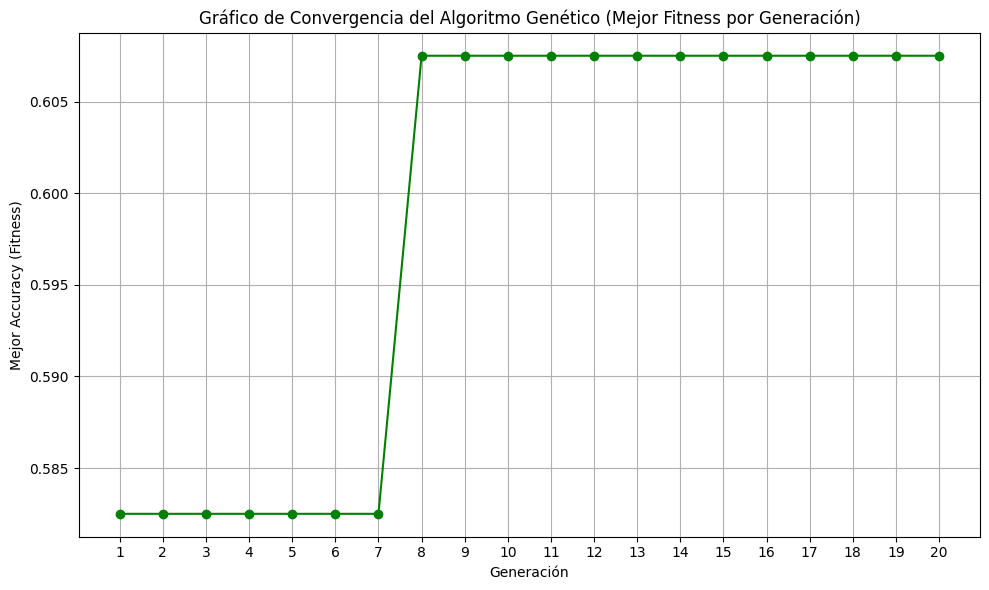


Entrenando el mejor modelo KNN con k=21 para la Matriz de Confusión...


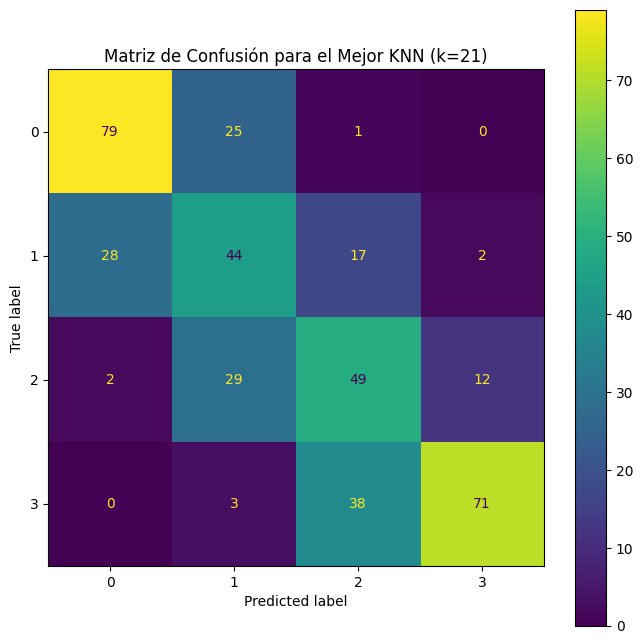


Comparando el modelo KNN por defecto vs. el optimizado por el AG...


/tmp/ipykernel_9372/478494473.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Accuracy', data=comparison_df, palette=['skyblue', 'lightcoral'])


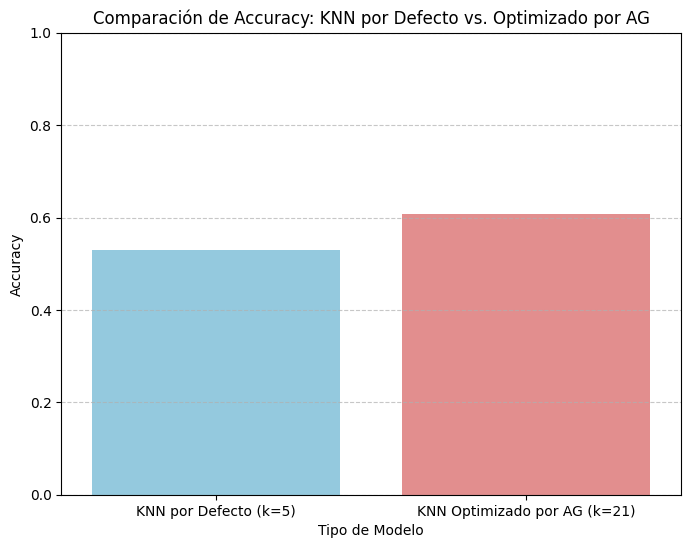

Accuracy del KNN por defecto (k=5): 0.5300
Accuracy del KNN optimizado por AG (k=21): 0.6075


In [ ]:
# Gráfico de Convergencia (Mejor Fitness vs. Generación)
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_generaciones + 1), best_fitness_history, marker='o', linestyle='-', color='g')
plt.title('Gráfico de Convergencia del Algoritmo Genético (Mejor Fitness por Generación)')
plt.xlabel('Generación')
plt.ylabel('Mejor Accuracy (Fitness)')
plt.grid(True)
plt.xticks(range(1, n_generaciones + 1))
plt.tight_layout()
plt.show()

# Matriz de Confusión del mejor modelo encontrado
print("\nEntrenando el mejor modelo KNN con k={} para la Matriz de Confusión...".format(mejor_cromosoma[0]))
best_k = mejor_cromosoma[0]
best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train_scaled, y_train)
y_pred_best_model = best_knn_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best_model)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn_model.classes_)
plt.figure(figsize=(8, 8))
disp.plot(cmap='viridis', ax=plt.gca())
plt.title(f'Matriz de Confusión para el Mejor KNN (k={best_k})')
plt.show()

# Comparativa visual: KNN con parámetros por defecto vs. optimizado por el AG
print("\nComparando el modelo KNN por defecto vs. el optimizado por el AG...")

# Modelo KNN con parámetros por defecto (usualmente k=5 si no se especifica)
default_knn_model = KNeighborsClassifier(n_neighbors=5) # n_neighbors por defecto de scikit-learn
default_knn_model.fit(X_train_scaled, y_train)
y_pred_default_model = default_knn_model.predict(X_test_scaled)
accuracy_default = accuracy_score(y_test, y_pred_default_model)

# Accuracy del modelo optimizado por AG (ya calculado como mejor_fitness_global)
accuracy_optimized = mejor_fitness_global

# Crear un DataFrame para la visualización
comparison_df = pd.DataFrame({
    'Modelo': ['KNN por Defecto (k=5)', f'KNN Optimizado por AG (k={best_k})'],
    'Accuracy': [accuracy_default, accuracy_optimized]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Modelo', y='Accuracy', data=comparison_df, palette=['skyblue', 'lightcoral'])
plt.ylim(0.0, 1.0) # Ajustar el límite y para mejor visualización de diferencias
plt.title('Comparación de Accuracy: KNN por Defecto vs. Optimizado por AG')
plt.ylabel('Accuracy')
plt.xlabel('Tipo de Modelo')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Accuracy del KNN por defecto (k=5): {accuracy_default:.4f}")
print(f"Accuracy del KNN optimizado por AG (k={best_k}): {accuracy_optimized:.4f}")
